<a href="https://colab.research.google.com/github/adrinorosario/legal-pragmatic-inference/blob/main/legal_inference_benchmarks_analysis_and_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding the data for Pragmatic Inference on Legal Language

## ContractNLI dataset

Loaded from [kiddothe2b/contract-nli](https://huggingface.co/datasets/kiddothe2b/contract-nli) from huggingface. Note: dataset scripts are no longer supported; hence parquet version loaded

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from datasets import load_dataset

# Load the automatically converted parquet version
dataset = load_dataset("kiddothe2b/contract-nli", revision="refs/convert/parquet")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


0000.parquet:   0%|          | 0.00/796k [00:00<?, ?B/s]

contractnli_b/train/0000.parquet:   0%|          | 0.00/2.18M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/345k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/213k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/631k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 14010
    })
    validation: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 2015
    })
    test: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 4082
    })
})

In [4]:
train_split, validation_split, test_split = dataset['train'], dataset['validation'], dataset['test']
print(f"train_split length: {len(train_split)}")
print(f"test_split length: {len(test_split)}")
print(f"validation_split length: {len(validation_split)}")

train_split length: 14010
test_split length: 4082
validation_split length: 2015


Corresponding labels taken from the dataset page

In [5]:
labels = {
    0: "contradiction",
    1: "entailment",
    2: "neutral",
}

In [6]:
import textwrap

print(f"{textwrap.fill(train_split[0]['premise'], width=80)} \n\n{train_split[0]['hypothesis']} \n\n{labels[train_split[0]['label']]}")

2.3 Provided that the Recipient has a written agreement with the following
persons or entities requiring them to treat the Confidential Information in
accordance with this Agreement, the Recipient may disclose the Confidential
Information to: 2.3.1  Any other party with the Discloser’s prior written
consent; and 2.3.2 the Recipient’s employees, officials, representatives and
agents who have a strict need to know the contents of the Confidential
Information, and employees, officials, representatives and agents of any legal
entity that it controls, controls it, or with which it is under common control,
who have a similar need to know the contents of the Confidential Information,
provided that, for these purposes a controlled legal entity means: 

Receiving Party shall not reverse engineer any objects which embody Disclosing Party's Confidential Information. 

neutral


In [7]:
import random

for i in range(0, 5):
  rand_idx = random.randint(0, len(train_split))

  premise = train_split[rand_idx]['premise']
  hypothesis = train_split[rand_idx]['hypothesis']
  label = train_split[rand_idx]['label']

  print(f"Premise: {textwrap.fill(premise, width=80)} \n\nHypothesis: {hypothesis} \n\nLabel: {labels[label]}")
  print()

Premise: MUTUAL NON-DISCLOSURE AGREEMENT This Mutual Non-Disclosure Agreement (the
“Agreement”) is made and entered into, as of May 8th, 2018 (“Effective Date”),
by and between FullStory, Inc., having a principal place of business at 120
Ottley Dr NE, Ste 100, Atlanta, GA 30324 and ____________, having a principal
place of business at ________________. 1. "Confidential Information"means
information that relates to the Purpose (as defined below) or that, although not
related to such Purpose, is nevertheless disclosed as a result of the parties'
discussions in that regard, and that should reasonably have been understood by
the party receiving such information (the “Recipient”), because of legends or
other markings, the circumstances of disclosure or the nature of the information
itself, to be proprietary and confidential to the party disclosing the
information (the “Discloser”) or an Affiliate of the Discloser or to a third
party. Confidential Information may be disclosed in written or o

The first data entry from the train split.

**Observations:**



1.   The premise is stating the nature of the contract clause. Seeing the above premise example, it is interpretable that it is meant to stop the recipient from disclosing any confidential information to parties of interest to them without prior written consent from the discloser
2.   The hypothesis is stating that the receiving party shall not reverse engineer (in the sense that they shall not deconstruct it to understand its logic and construction) anything that the confidential information is carrying
3. The label for this is neutral



In [8]:
premise_token_count = 0
n = 25
iterations = 4

for iteration in range(iterations):
  for clause in range(n):
    premise = train_split[clause]['premise']
    word_tokens = set(premise.split())
    premise_token_count += len(word_tokens)

  print(f"Iteration: {iteration} | Number of premises scanned: {n}")
  print(f"Average token count of the first {n} premises: {premise_token_count/n}")
  print()
  n += int((25/100) * 100)
  premise_token_count = 0

Iteration: 0 | Number of premises scanned: 25
Average token count of the first 25 premises: 42.32

Iteration: 1 | Number of premises scanned: 50
Average token count of the first 50 premises: 41.78

Iteration: 2 | Number of premises scanned: 75
Average token count of the first 75 premises: 40.013333333333335

Iteration: 3 | Number of premises scanned: 100
Average token count of the first 100 premises: 42.41



It is observed that each premise in the contract clause has an average of 40-42 words in it.

In [9]:
vague_legal_terms = {
    # Effort & diligence
    "reasonable efforts",
    "best efforts",
    "commercially reasonable",
    "due diligence",
    "reasonable care",
    "good faith",

    # Time & urgency
    "promptly",
    "in a timely manner",
    "as soon as practicable",
    "without undue delay",
    "for a reasonable period",
    "termination of this Agreement",

    # Scope & degree
    "material",
    "substantial",
    "limited",
    "relevant",
    "related",
    "generally",
    "appropriate",
    "similar",

    # Necessity & discretion
    "necessary",
    "sole discretion",
    "need to know",
    "confidential nature",
    "adequate",
    "satisfactory",
    "proper",
    "intended purpose",

    # Industry norms
    "customary",
    "ordinary course of business",
    "industry standard",
    "standard practice",
    "normally",
    "comparable",
    "acceptable",
    "conventional",

    # Knowledge & foresight
    "foreseeable",
    "contemplated",
    "intended",
    "anticipated",
    "applicable",
    "knowledge",
    "directly or indirectly",
    "disclosed in confidence",
    "all copies",
    "survive",
    "mutual agreement",
    "substantially similar",
}

print(f"Length of vague_legal_terms: {len(vague_legal_terms)}")

Length of vague_legal_terms: 48


In [21]:
premise_token_count = 0
vague_term_count = 0
prev_vague_term_count = 0
n = 25
iterations = 10

cummulative_vague_term_count = dict()

for iteration in range(iterations):
  for clause in range(n):
    premise = train_split[clause]['premise']
    word_tokens = set(premise.split())
    premise_token_count += len(word_tokens)
    vague_terms_in_premise = [word for word in vague_legal_terms if word in premise]
    vague_term_count += len(vague_terms_in_premise)


  print(f"Iteration: {iteration} | Number of premises scanned: {n}")
  print(f"Average token count of the first {n} premises: {premise_token_count/n: .2f}")
  print(f"Total number of vague terms found in {n} premises: {vague_term_count}")
  print(f"Average count of vague terms found in {n} premises: {vague_term_count/n: .2f}")

  if prev_vague_term_count == 0:
    if vague_term_count == 0:
      print("No vague term found")
    else:
      print(f"Percentage increase in vague term count: N/A (0.0%)")
      percentage_increase_in_vague_term_count = 0.0
  else:
    percentage_increase_in_vague_term_count = ((vague_term_count - prev_vague_term_count)/prev_vague_term_count) * 100
    print(f"Increase from previous iteration: {percentage_increase_in_vague_term_count: .2f}%")
  print()

  dict_value = {
      "premise_count": n,
      "word_token_counts": premise_token_count,
      "vague_term_count": vague_term_count,
      "percentage_increase_in_vague_term_count": percentage_increase_in_vague_term_count,
  }

  cummulative_vague_term_count[iteration] = dict_value

  n += int((25/100) * 100)
  premise_token_count = 0
  prev_vague_term_count = vague_term_count
  vague_term_count = 0

Iteration: 0 | Number of premises scanned: 25
Average token count of the first 25 premises:  42.32
Total number of vague terms found in 25 premises: 20
Average count of vague terms found in 25 premises:  0.80
Percentage increase in vague term count: N/A (0.0%)

Iteration: 1 | Number of premises scanned: 50
Average token count of the first 50 premises:  41.78
Total number of vague terms found in 50 premises: 34
Average count of vague terms found in 50 premises:  0.68
Increase from previous iteration:  70.00%

Iteration: 2 | Number of premises scanned: 75
Average token count of the first 75 premises:  40.01
Total number of vague terms found in 75 premises: 49
Average count of vague terms found in 75 premises:  0.65
Increase from previous iteration:  44.12%

Iteration: 3 | Number of premises scanned: 100
Average token count of the first 100 premises:  42.41
Total number of vague terms found in 100 premises: 79
Average count of vague terms found in 100 premises:  0.79
Increase from previou

In [22]:
cummulative_vague_term_count

{0: {'premise_count': 25,
  'word_token_counts': 1058,
  'vague_term_count': 20,
  'percentage_increase_in_vague_term_count': 0.0},
 1: {'premise_count': 50,
  'word_token_counts': 2089,
  'vague_term_count': 34,
  'percentage_increase_in_vague_term_count': 70.0},
 2: {'premise_count': 75,
  'word_token_counts': 3001,
  'vague_term_count': 49,
  'percentage_increase_in_vague_term_count': 44.11764705882353},
 3: {'premise_count': 100,
  'word_token_counts': 4241,
  'vague_term_count': 79,
  'percentage_increase_in_vague_term_count': 61.224489795918366},
 4: {'premise_count': 125,
  'word_token_counts': 5359,
  'vague_term_count': 99,
  'percentage_increase_in_vague_term_count': 25.31645569620253},
 5: {'premise_count': 150,
  'word_token_counts': 6822,
  'vague_term_count': 128,
  'percentage_increase_in_vague_term_count': 29.292929292929294},
 6: {'premise_count': 175,
  'word_token_counts': 9037,
  'vague_term_count': 165,
  'percentage_increase_in_vague_term_count': 28.90625},
 7: {'

In [23]:
vague_term_counts = []
percentage_increases = []
premise_counts = []
word_token_counts = []

for key, value in cummulative_vague_term_count.items():
  premise_counts.append(cummulative_vague_term_count[key]['premise_count'])
  vague_term_counts.append(cummulative_vague_term_count[key]['vague_term_count'])
  percentage_increases.append(cummulative_vague_term_count[key]['percentage_increase_in_vague_term_count'])
  word_token_counts.append(cummulative_vague_term_count[key]['word_token_counts'])

<Axes: >

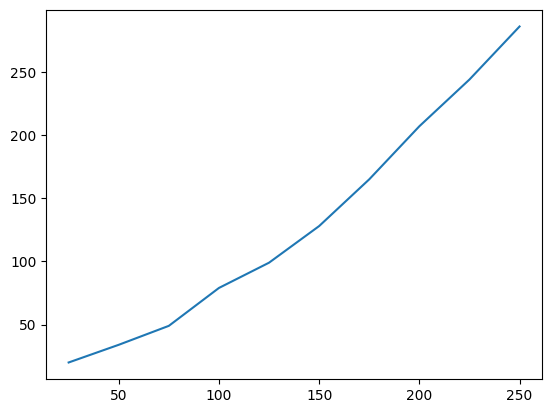

In [24]:
sns.lineplot(x=premise_counts, y=vague_term_counts)

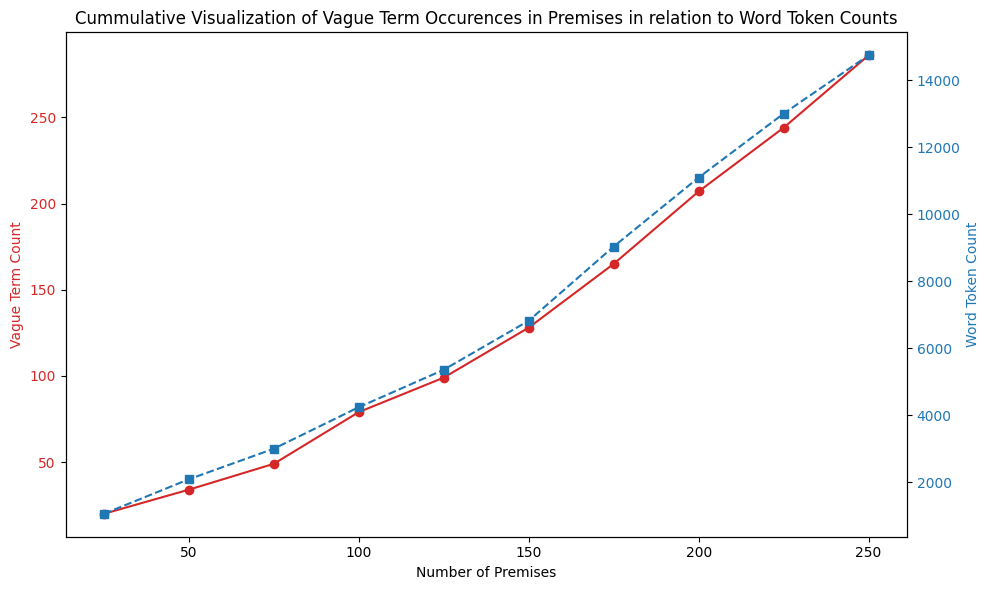

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Number of Premises')
ax1.set_ylabel('Vague Term Count', color='tab:red')
ax1.plot(premise_counts, vague_term_counts, color='tab:red', marker='o', label='Vague Terms')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Word Token Count', color='tab:blue')
ax2.plot(premise_counts, word_token_counts, color='tab:blue', marker='s', linestyle='--', label='Word Tokens')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Cummulative Visualization of Vague Term Occurences in Premises in relation to Word Token Counts')
fig.tight_layout()
plt.show()

In [26]:
hypothesis_vague_term_count = 0
prev_vague_term_count = 0
n = 25
iterations = 10

cummulative_vague_term_count_in_hypothesis = dict()

for iteration in range(iterations):
  # Resetting local count for calculation of percentage increase if needed
  # but we want hypothesis_vague_term_count to represent the total up to n
  hypothesis_vague_term_count = 0
  for clause in range(n):
    hypothesis = train_split[clause]['hypothesis']
    word_tokens = set(hypothesis.split())
    vague_terms_in_hypothesis = [word for word in vague_legal_terms if word in hypothesis]
    hypothesis_vague_term_count += len(vague_terms_in_hypothesis)


  print(f"Iteration: {iteration} | Number of hypothesis scanned: {n}")
  print(f"Total number of vague terms found in {n} hypotheses: {hypothesis_vague_term_count}")
  print(f"Average count of vague terms found in {n} hypothesis: {hypothesis_vague_term_count/n: .2f}")

  if prev_vague_term_count == 0:
    if hypothesis_vague_term_count == 0:
      print("No vague term found")
    else:
      print(f"Percentage increase in vague term count: N/A (0.0%)")
      percentage_increase_in_vague_term_count = 0.0
  else:
    percentage_increase_in_vague_term_count = ((hypothesis_vague_term_count - prev_vague_term_count)/prev_vague_term_count) * 100
    print(f"Increase from previous iteration: {percentage_increase_in_vague_term_count: .2f}%")
  print()

  dict_value = {
      "hypothesis_count": n,
      "hypothesis_vague_term_count": hypothesis_vague_term_count,
      "percentage_increase_in_vague_term_count": percentage_increase_in_vague_term_count,
  }

  cummulative_vague_term_count_in_hypothesis[iteration] = dict_value

  n += int((25/100) * 100)
  prev_vague_term_count = hypothesis_vague_term_count
  # hypothesis_vague_term_count = 0  <-- Removed this reset so it can represent the total for the next 'n'

Iteration: 0 | Number of hypothesis scanned: 25
Total number of vague terms found in 25 hypotheses: 5
Average count of vague terms found in 25 hypothesis:  0.20
Percentage increase in vague term count: N/A (0.0%)

Iteration: 1 | Number of hypothesis scanned: 50
Total number of vague terms found in 50 hypotheses: 9
Average count of vague terms found in 50 hypothesis:  0.18
Increase from previous iteration:  80.00%

Iteration: 2 | Number of hypothesis scanned: 75
Total number of vague terms found in 75 hypotheses: 12
Average count of vague terms found in 75 hypothesis:  0.16
Increase from previous iteration:  33.33%

Iteration: 3 | Number of hypothesis scanned: 100
Total number of vague terms found in 100 hypotheses: 16
Average count of vague terms found in 100 hypothesis:  0.16
Increase from previous iteration:  33.33%

Iteration: 4 | Number of hypothesis scanned: 125
Total number of vague terms found in 125 hypotheses: 21
Average count of vague terms found in 125 hypothesis:  0.17
Incr

In [27]:
hypothesis_vague_term_counts = []
hypothesis_percentage_increases = []
hypothesis_counts = []

for key, value in cummulative_vague_term_count_in_hypothesis.items():
  hypothesis_counts.append(cummulative_vague_term_count_in_hypothesis[key]['hypothesis_count'])
  hypothesis_vague_term_counts.append(cummulative_vague_term_count_in_hypothesis[key]['hypothesis_vague_term_count'])
  hypothesis_percentage_increases.append(cummulative_vague_term_count_in_hypothesis[key]['percentage_increase_in_vague_term_count'])

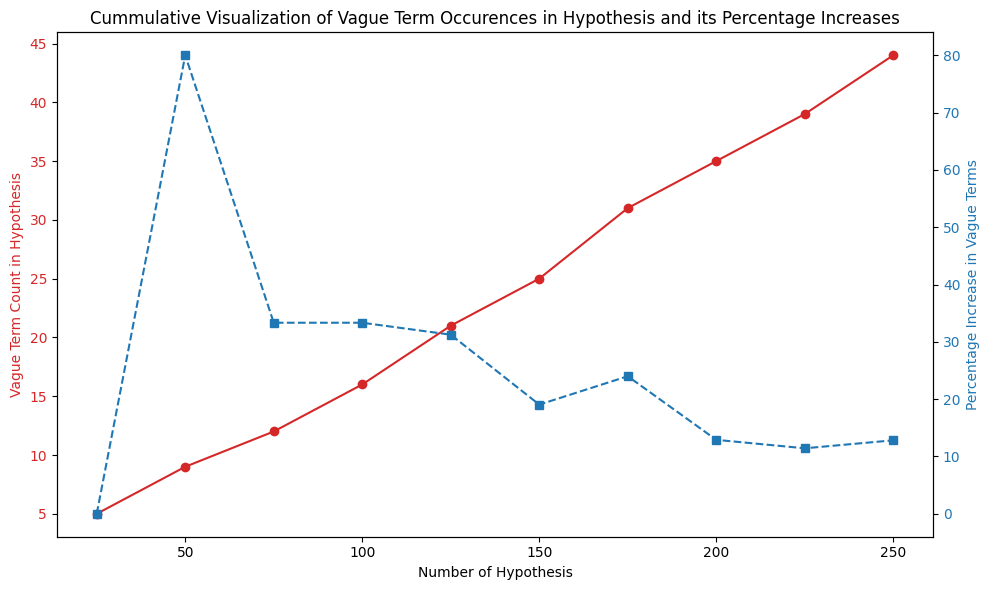

In [28]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Number of Hypothesis')
ax1.set_ylabel('Vague Term Count in Hypothesis', color='tab:red')
ax1.plot(hypothesis_counts, hypothesis_vague_term_counts, color='tab:red', marker='o', label='Vague Terms')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Percentage Increase in Vague Terms', color='tab:blue')
ax2.plot(hypothesis_counts, hypothesis_percentage_increases, color='tab:blue', marker='s', linestyle='--', label='Percentage Increase')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Cummulative Visualization of Vague Term Occurences in Hypothesis and its Percentage Increases')
fig.tight_layout()
plt.show()

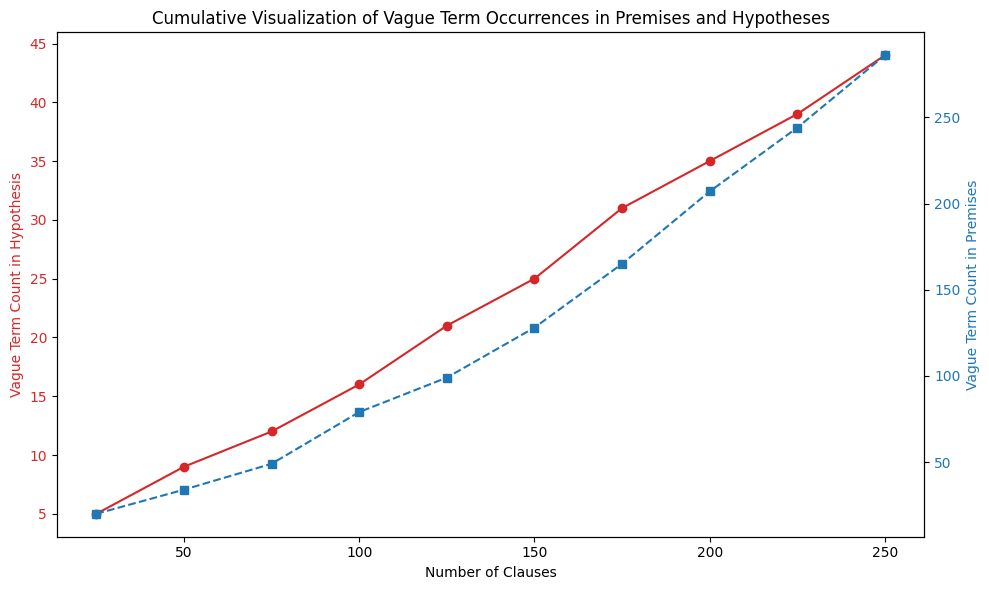

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Number of Clauses')
ax1.set_ylabel('Vague Term Count in Hypothesis', color='tab:red')
ax1.plot(hypothesis_counts, hypothesis_vague_term_counts, color='tab:red', marker='o', label='Hypothesis Vague Terms')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Vague Term Count in Premises', color='tab:blue')
ax2.plot(premise_counts, vague_term_counts, color='tab:blue', marker='s', linestyle='--', label='Premise Vague Terms')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Cumulative Visualization of Vague Term Occurrences in Premises and Hypotheses')
fig.tight_layout()
plt.show()

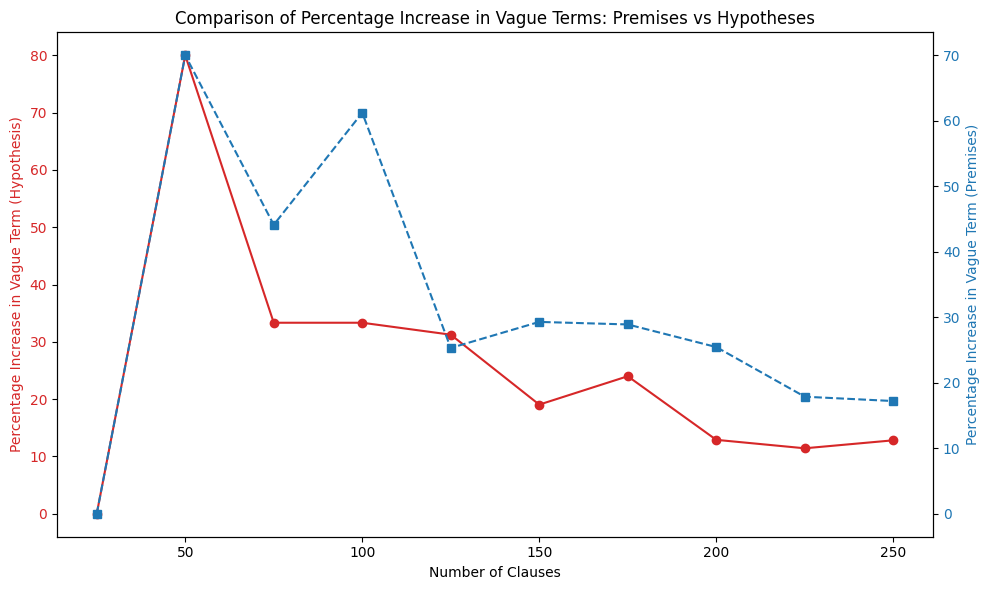

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Number of Clauses')
ax1.set_ylabel('Percentage Increase in Vague Term (Hypothesis)', color='tab:red')
ax1.plot(hypothesis_counts, hypothesis_percentage_increases, color='tab:red', marker='o', label='Hypothesis % Increase')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Percentage Increase in Vague Term (Premises)', color='tab:blue')
ax2.plot(premise_counts, percentage_increases, color='tab:blue', marker='s', linestyle='--', label='Premise % Increase')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Comparison of Percentage Increase in Vague Terms: Premises vs Hypotheses')
fig.tight_layout()
plt.show()

Total records scanned to find 100 neutral ones: 242
Count of neutral premises collected: 100


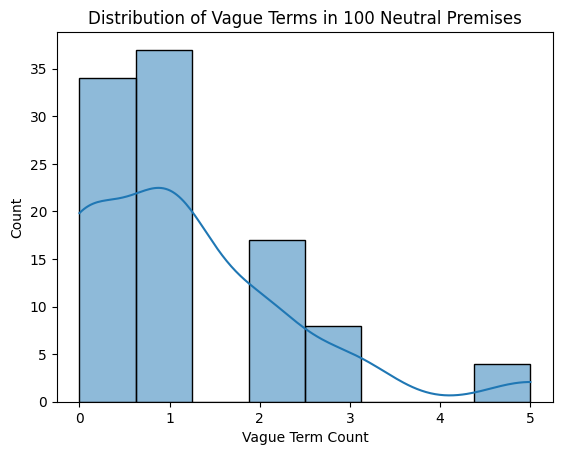

In [44]:
n = 0
num_vague_terms_in_premises_where_neutral = []

while len(num_vague_terms_in_premises_where_neutral) < 100 and n < len(train_split):
  if train_split[n]['label'] == 2:
    premise = train_split[n]['premise']
    vague_terms_count = len([word for word in vague_legal_terms if word in premise])
    num_vague_terms_in_premises_where_neutral.append(vague_terms_count)

  n += 1

sns.histplot(num_vague_terms_in_premises_where_neutral, kde=True)
plt.title('Distribution of Vague Terms in 100 Neutral Premises')
plt.xlabel('Vague Term Count')
print(f"Total records scanned to find 100 neutral ones: {n}")
print(f"Count of neutral premises collected: {len(num_vague_terms_in_premises_where_neutral)}")

(<Axes: ylabel='Count'>, 66)

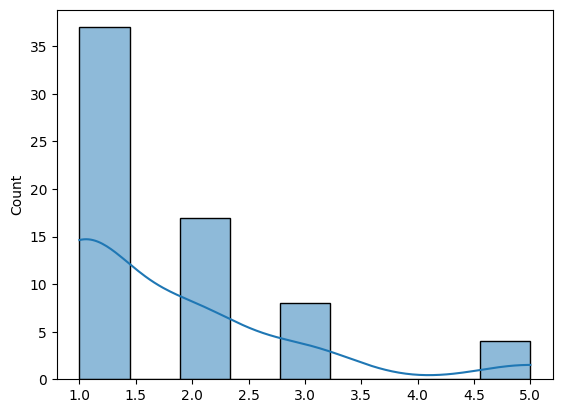

In [45]:
non_zero_vague_term_counts_for_neutral_labels = [count for count in num_vague_terms_in_premises_where_neutral if count > 0]
sns.histplot(non_zero_vague_term_counts_for_neutral_labels, kde=True), len(non_zero_vague_term_counts_for_neutral_labels)